In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

In [3]:
files = ["../../course_assignments/homework10/M13_0001.fits",
        "../../course_assignments/homework10/M13_0002.fits",
        "../../course_assignments/homework10/M13_0003.fits",
        "../../course_assignments/homework10/M13_0004.fits",
        "../../course_assignments/homework10/M13_0005.fits"]

headers = []
datas = []

for file in files:
    with fits.open(file) as hdul:
        headers.append(hdul[0].header)
        datas.append(hdul[0].data)

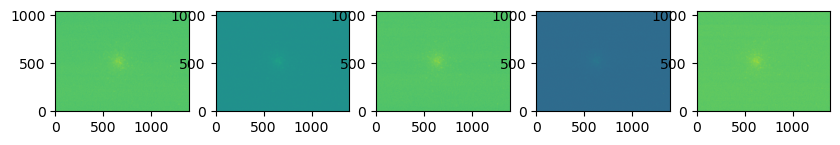

In [25]:
fig, axes = plt.subplots(1,5, figsize = (10,2))
for i in range(5):
    axes[i].imshow(datas[i], origin = "lower")
plt.show()

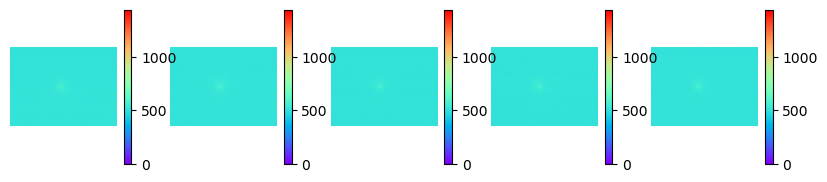

In [24]:
vmin = np.min(datas)
vmax = np.max(datas)

fig, axes2 = plt.subplots(1,5, figsize = (10,2))
for i in range(5):
    im = axes2[i].imshow(datas[i], cmap = "rainbow", vmin = vmin, vmax = vmax, origin = "lower")
    fig.colorbar(im, ax=axes2[i])
    axes2[i].axis("off")
plt.show()

In [26]:
# 3.2.2 What differences do you notice in the images compared to the previous subplots?
# In the original subplots, there were two darker green-blue plots (2 and 4) and the others were green (1, 3, and 5)
# In all, there is a faint spot in the center of the plot.
# In the new subplots, the graphs look nearly identical -- they are a turqiose color with 
# still a faint light spot at the center.

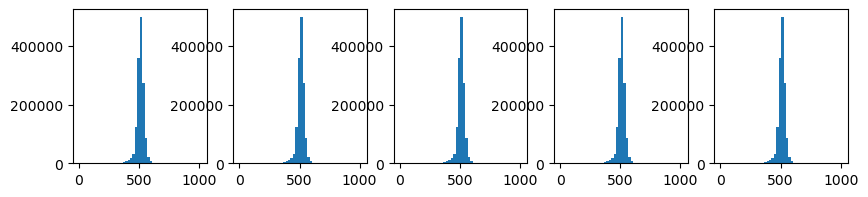

In [33]:
fig, axh = plt.subplots(1,5, figsize = (10, 2))
for i in range(5):
    axh[i].hist(datas[1].ravel(), bins = 50)
plt.show()

In [37]:
# 3.3.2 Answer the following:
# (a) What value is on the x-axis? y-axis?
# On the x-axis, there are pixel values (on a scale from 0 to 1000)
# On the y-axis, the pixel counts are listed. 
# To read this mapping: vertical peaks represent the number of pixels (y-axis) with a specified 
# pixel value (the x-axis)
# (b) What does bins = 50 mean?
# bins = 50 tells matplotlib the number of bins to sort the x-values into. Since we have bins = 50, 
# The 1000 possible pixel values are sorted into 50 bins -- that is, each bin has 20 pixels.
# A larger bin number means more bins and a smoother plot (bins = 1000 would graph the pixel count for 
# each separate pixel value 0, 1, 2, 3, ... This takes longer to load but produces a smoother histogram)
# (c) Where is most of the data centered for pixel intensity?
# Most of the data is centered at an intensity of 500.
# (d) How spread out is the data? Ignore the outliers.
# The data has about a 100 pixel intensity spread (not very much out of 1000)
# (e) What is the median/mean pixel intensity value for each image?
mean = []
median = []
for i in range(5):
    mean.append(np.mean(datas[i]))
    median.append(np.median(datas[i]))
for i in range(5):
    print(f"The mean pixel intensity for image {i+1} is {mean[i]}.\nThe median pixel intensity for image {i+1} is {median[i]}.")

The mean pixel intensity for image 1 is 510.4706668600796.
The median pixel intensity for image 1 is 512.0.
The mean pixel intensity for image 2 is 509.7460150033157.
The median pixel intensity for image 2 is 511.0.
The mean pixel intensity for image 3 is 508.0498729000884.
The median pixel intensity for image 3 is 510.0.
The mean pixel intensity for image 4 is 507.90583554376656.
The median pixel intensity for image 4 is 509.0.
The mean pixel intensity for image 5 is 508.7919920148099.
The median pixel intensity for image 5 is 510.0.


In [39]:
datas[0]

array([[489, 474, 519, ..., 447, 541, 519],
       [517, 508, 489, ..., 517, 490, 499],
       [500, 453, 518, ..., 537, 514, 537],
       ...,
       [449, 490, 519, ..., 469, 508, 541],
       [500, 521, 514, ..., 502, 478, 549],
       [480, 516, 535, ..., 494, 527, 491]],
      shape=(1040, 1392), dtype=uint16)

In [44]:
combined_image = np.median(datas, axis = 0)
combined_median = np.median(combined_image)
print(f"The median pixel intensity of the combined image is {combined_median}.")

The median pixel intensity of the combined image is 510.0.


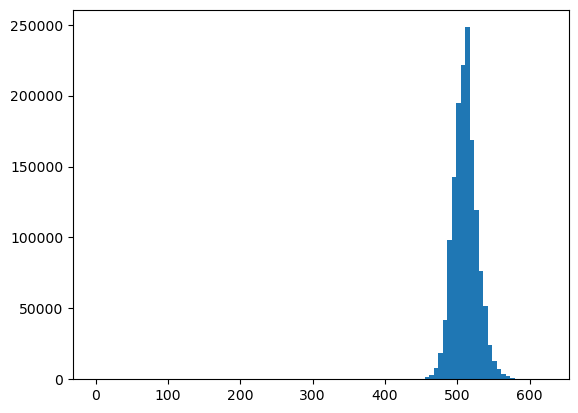

In [47]:
plt.hist(combined_image.ravel(), bins = 100)
plt.show()

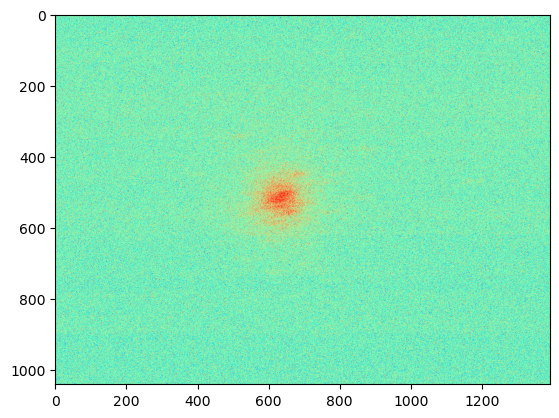

In [52]:
plt.figure()
plt.imshow(combined_image, vmin = 450, vmax = 575, cmap = "rainbow")
plt.show()
# This image is slightly more defined than the previous images. I can begin to identify the
# edges of the bright spot in the center.

In [54]:
fits.writeto("combined.fits", combined_image, overwrite = True)

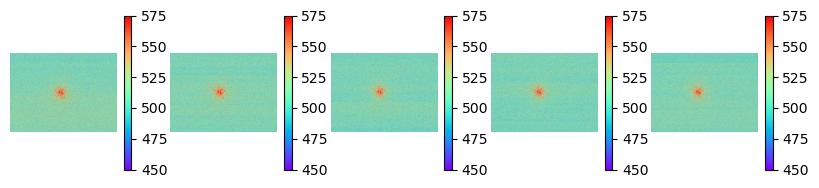

In [55]:
fig, axes3 = plt.subplots(1,5, figsize = (10,2))
for i in range(5):
    im = axes3[i].imshow(datas[i], cmap = "rainbow", vmin = 450, vmax = 575, origin = "lower")
    fig.colorbar(im, ax=axes3[i])
    axes3[i].axis("off")
plt.show()